In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [30]:
def extract_values(line):
    pattern = re.compile(r'(\w+)\s(\w+)\s(\d+):\s([\w\d\.\=,%\s]+)')
    match = pattern.match(line)
    if match:
        values = match.group(4)
        values_dict = dict(item.split('=') for item in values.split(', '))
        return int(match.group(3)), values_dict
    return None, None

def read_report(file_path, metric, train=True):
    epochs = []
    values_list = []
    epoch_type = "Train" if train else "Test"

    with open(file_path, 'r') as file:
        for line in file:
            if f"{epoch_type} epoch" in line:
                epoch, values = extract_values(line)
                if epoch is not None:
                    epochs.append(epoch)
                    values_list.append(float(values[metric].replace('%', '')))
    
    return pd.DataFrame({'Epoch': epochs, metric: values_list})

def plot_metric(file_paths, labels, metric, train, title, xlabel, ylabel, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    
    for file_path, label in zip(file_paths, labels):
        data = read_report(file_path, metric, train)
        plt.plot(data['Epoch'], data[metric], marker='o', linestyle='-', label=label)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(False)
    plt.tight_layout()  
    plt.show()



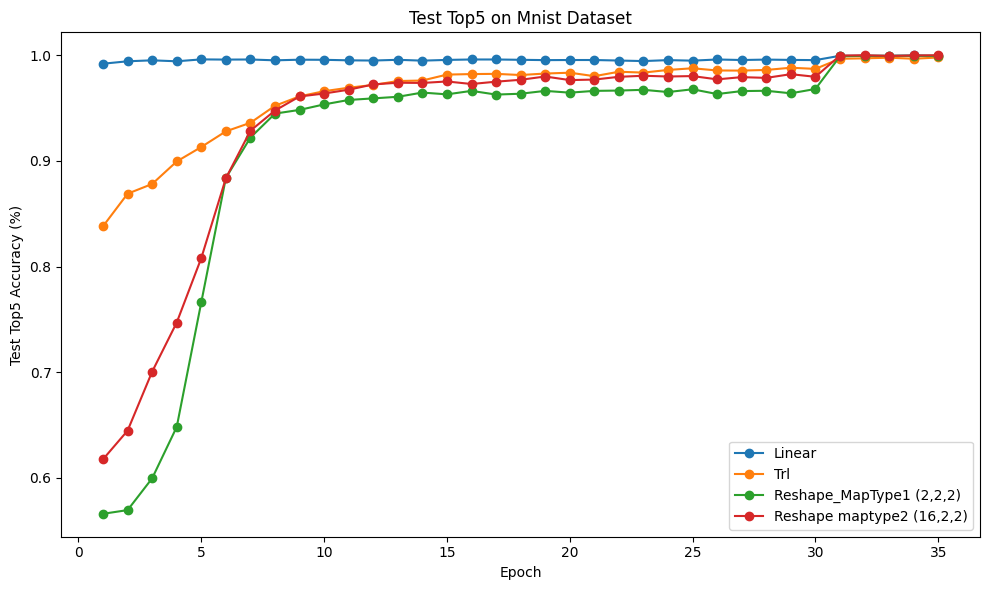

In [31]:
file_paths = [
    '../results/Test_ID001/accuracy_stats/report.txt',
    '../results/Test_ID004/accuracy_stats/report.txt',
    '../results/Test_ID007/accuracy_stats/report.txt',
    '../results/Test_ID010/accuracy_stats/report.txt'
]

labels = ['Linear', 'Trl', 'Reshape_MapType1 (2,2,2)', 'Reshape maptype2 (16,2,2)']
metric = 'top5'  
train = False  
title = 'Test Top5 on Mnist Dataset'  
xlabel = 'Epoch'
ylabel = 'Test Top5 Accuracy (%)'  

plot_metric(file_paths, labels, metric, train, title, xlabel, ylabel)


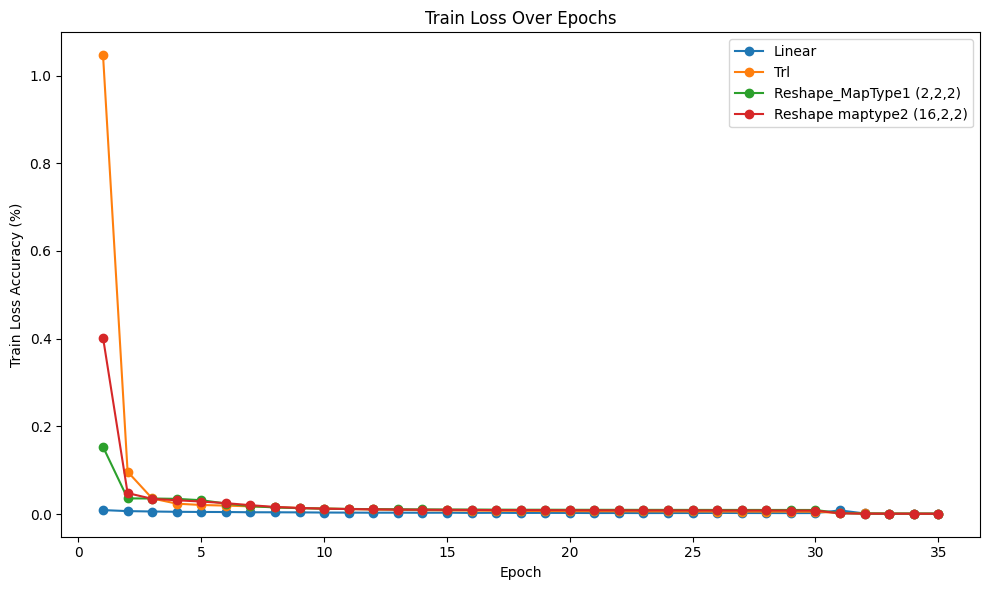

In [32]:

metric = 'loss'  
train = True  
title = 'Train Loss Over Epochs'  
xlabel = 'Epoch'
ylabel = 'Train Loss Accuracy (%)'  

plot_metric(file_paths, labels, metric, train, title, xlabel, ylabel)

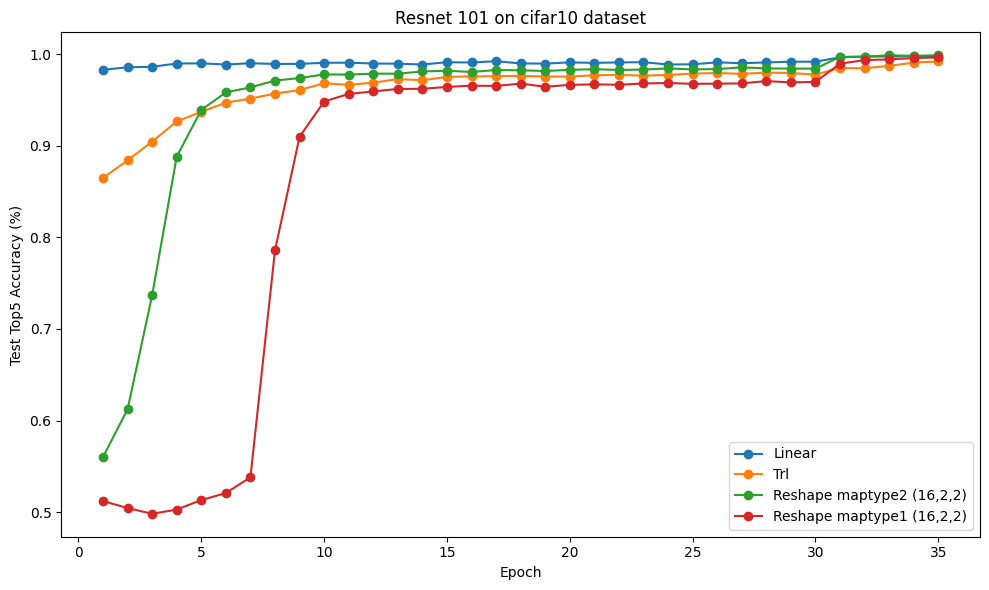

In [33]:
file_paths = [
    '../results/Test_ID049/accuracy_stats/report.txt',
    '../results/Test_ID052/accuracy_stats/report.txt',
    '../results/Test_ID058/accuracy_stats/report.txt',
    '../results/Test_ID059/accuracy_stats/report.txt'
]

labels = ['Linear', 'Trl', 'Reshape maptype2 (16,2,2)', 'Reshape maptype1 (16,2,2)']
metric = 'top5'  
train = False  
title = 'Resnet 101 on cifar10 dataset'  
xlabel = 'Epoch'
ylabel = 'Test Top5 Accuracy (%)'  

plot_metric(file_paths, labels, metric, train, title, xlabel, ylabel)


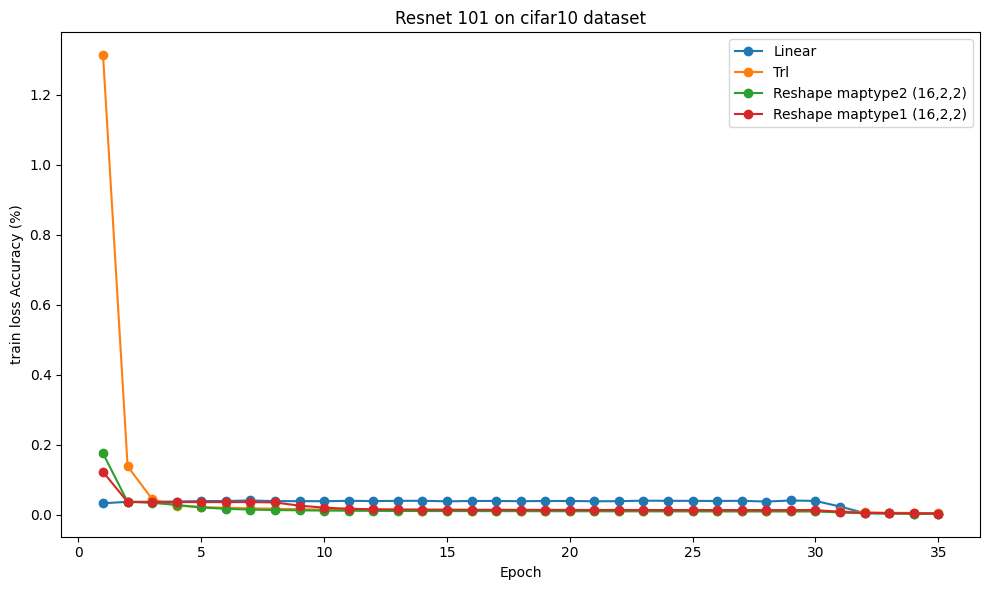

In [34]:
metric = 'loss'  
train = True  
xlabel = 'Epoch'
ylabel = 'train loss Accuracy (%)'  

plot_metric(file_paths, labels, metric, train, title, xlabel, ylabel)


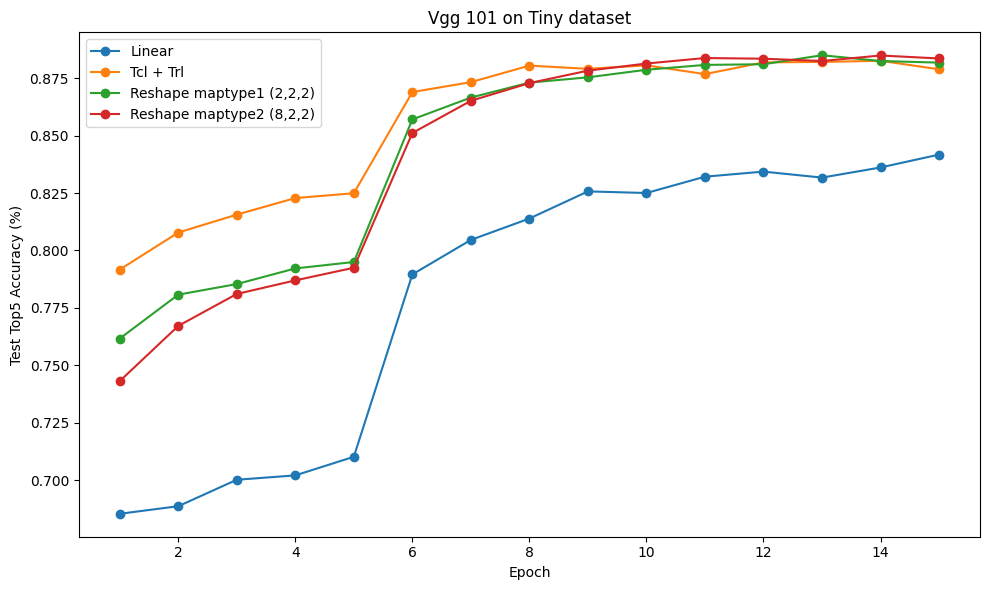

In [35]:
file_paths = [
    '../results/Test_ID085/accuracy_stats/report.txt',
    '../results/Test_ID086/accuracy_stats/report.txt',
    '../results/Test_ID087/accuracy_stats/report.txt',
    '../results/Test_ID090/accuracy_stats/report.txt'
]

labels = ['Linear', 'Tcl + Trl', 'Reshape maptype1 (2,2,2)', 'Reshape maptype2 (8,2,2)']
metric = 'top5'  
train = False  
title = 'Vgg 101 on Tiny dataset'  
xlabel = 'Epoch'
ylabel = 'Test Top5 Accuracy (%)'  

plot_metric(file_paths, labels, metric, train, title, xlabel, ylabel)

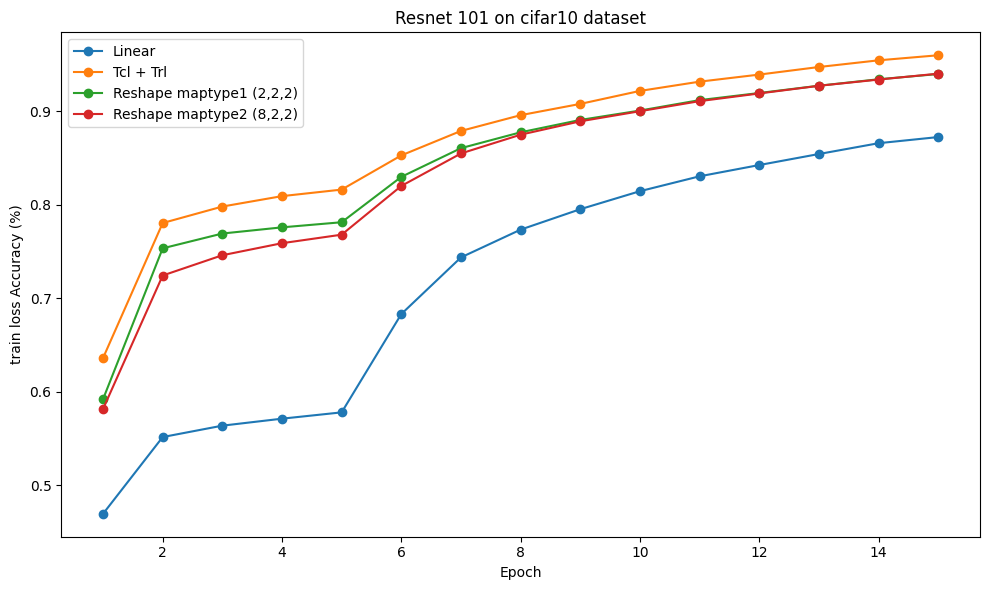

In [36]:
metric = 'top5'  
train = True  
title = 'Resnet 101 on cifar10 dataset'  
xlabel = 'Epoch'
ylabel = 'train loss Accuracy (%)'  

plot_metric(file_paths, labels, metric, train, title, xlabel, ylabel)